# Clasificación de Trastornos del Lenguaje — CHILDES
## Pipeline de entrenamiento y evaluación comparativa de modelos

Este notebook entrena y compara tres modelos de clasificación  para distinguir entre:
- **Control (0):** niños con desarrollo típico (TD)
- **Experimental (1):** niños con trastornos que afectan el lenguaje lenguaje (DS, HL, LT, SLI)

Se utilizan los datos disponibles en metric_by_file.csv obtenidos del pipeline de extracción de features

### Modelos evaluados

1. Random Forest 

2. XGBoost 

3. LightGBM


In [ ]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import lightgbm as lgb

# Establecemos un random state para reproducibilida
RANDOM_STATE = 42


## paso 1 — Preparación de datos

In [ ]:
# Importamos los datos
df = pd.read_csv('metrics_by_file.csv')

# Codificamos nuestro target para que tenga una clasificación binaria
df['label'] = (df['group'] == 'experimental').astype(int)

# Eliminar columnas sin información útil
DROP_COLS = ['file_name', 'file_path', 'disorder_code', 'disorder_label', 'group']
df_clean = df.drop(columns=DROP_COLS, errors='ignore')

# Eliminar features con alta correlacion (> 0.90) para evitar redundancia entre las features
corr_matrix = df_clean.drop(columns=['label']).corr(method='pearson').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

print(f'Features eliminadas ({len(to_drop)}):')
print(to_drop)

X = df_clean.drop(columns=['label'] + to_drop)
y = df_clean['label']

print(f'\nFeatures finales: {X.shape[1]}')
print(f'Muestras totales: {X.shape[0]}')

# Al haber alta redundancia entre algunas de las features, se puede extraer información similar en las features sobrevivientes si son importantes para el modelo

Features eliminadas por correlacion alta (18):
['n_tokens', 'n_types', 'unique_words', 'hapax_legomena', 'common_word_token_count', 'n_utterances', 'n_nonempty_utterances', 'short_utterance_ratio_1_to_3', 'syntactic_tree_depth_mean', 'spacy_parsed_utterances', 'tfidf_utterances', 'spacy_vector_centroid_distance', 'spacy_vector_norm_mean', 'spacy_docs_with_vectors', 'unique_utterance_count', 'repeated_utterance_ratio', 'repeated_token_ratio', 'mean_adjacent_length_change']

Features finales: 37
Muestras totales: 10545


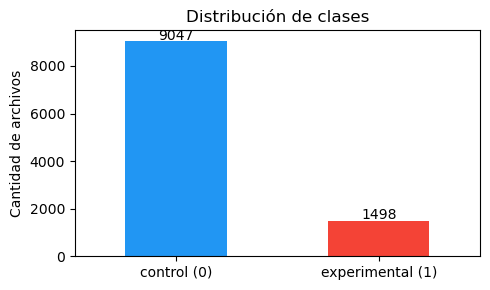

Ratio desbalance train: 6.0:1
Train: 8436 muestras | Test: 2109 muestras


In [ ]:
# Creamos la idvisión entre entrenamiento y prueba y estratificamom
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Exploramos en los datos restantes el desbalance que existe
fig, ax = plt.subplots(figsize=(5, 3))
pd.Series({'control (0)': (y==0).sum(), 'experimental (1)': (y==1).sum()}).plot(
    kind='bar', ax=ax, color=['#2196F3', '#F44336']
)
ax.set_title('Distribución de clases')
ax.set_ylabel('Cantidad de archivos')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            int(bar.get_height()), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

ratio = (y_train==0).sum() / (y_train==1).sum()
print(f'Ratio desbalance train: {ratio:.1f}:1')
print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')

Se puede identificar un desbalance importante entre los grupos, por lo cual es necesario tomar esto en cuenta al entrenar los modelos

---
## Paso 2 — Random Forest



In [ ]:
# Creamos una función 
results_list = []

def evaluate_model(name, y_test, y_prob, ax_cm=None, ax_roc=None):
    # Encuentra el Umbral optimo por F1 experimental, con el propósito de mejorar la clasificación minoritaria
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = f1.argmax()
    # Guarda el umbral óptimo para cada modelo
    best_threshold = thresholds[best_idx]

    # Utiliza el umbral óptimo para convertir probabilidades en predicciones binarias
    y_pred = (y_prob >= best_threshold).astype(int)
    report = classification_report(
        y_test, y_pred,
        target_names=['control', 'experimental'],
        output_dict=True
    )
    roc_auc = roc_auc_score(y_test, y_prob)

    # Imprime los resultados
    print(f'Umbral optimo : {best_threshold:.3f}')
    print(f'ROC-AUC       : {roc_auc:.4f}\n')
    print(classification_report(y_test, y_pred, target_names=['control', 'experimental']))

    # Visualiza la matriz de confusión y la curva Roc
    if ax_cm is not None:
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, display_labels=['control', 'experimental'], ax=ax_cm
        )
        ax_cm.set_title(f'Confusion Matrix — {name}')

    if ax_roc is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax_roc, name=name)
        ax_roc.set_title(f'ROC Curve — {name} (AUC={roc_auc:.3f})')
    
    # Guarda los resultados en la lista para comparación posterior
    results_list.append({
        'Modelo'        : name,
        'ROC-AUC'       : round(roc_auc, 4),
        'Precision (exp)': round(report['experimental']['precision'], 4),
        'Recall (exp)'  : round(report['experimental']['recall'], 4),
        'F1 (exp)'      : round(report['experimental']['f1-score'], 4),
        'F1 macro'      : round(report['macro avg']['f1-score'], 4),
        'Umbral'        : round(float(best_threshold), 3)
    })

    return y_pred, best_threshold

# Se utiliza una estratificación por K-fold para todos los modelos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [ ]:
# Se utiliza SMOTE para balancear las clases
# Este es un método de sobremuestreo que utiliza knn para generar nuevas muestras sintéticas de la clase minoritaria
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# DEfinimos un greed de hiperparámetros
rf_params = {
    'rf__n_estimators'     : [200, 300, 500],
    'rf__max_depth'        : [None, 20, 30],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf' : [1, 2],
    'rf__max_features'     : ['sqrt', 'log2'],
}

# Utilziamos un random search para encontrar los mejor hiperparámetros que optimicen ROC-AUC
rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params,
    n_iter=20, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

# Entrenamos el modelo con el mejor hiperparámetro encontrado
rf_search.fit(X_train, y_train)

print(f'Mejores parametros : {rf_search.best_params_}')
print(f'Mejor ROC-AUC (CV) : {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parametros : {'rf__n_estimators': 500, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__max_depth': 30}
Mejor ROC-AUC (CV) : 0.8181


Umbral optimo : 0.432
ROC-AUC       : 0.8349

              precision    recall  f1-score   support

     control       0.93      0.84      0.89      1809
experimental       0.41      0.64      0.50       300

    accuracy                           0.82      2109
   macro avg       0.67      0.74      0.69      2109
weighted avg       0.86      0.82      0.83      2109



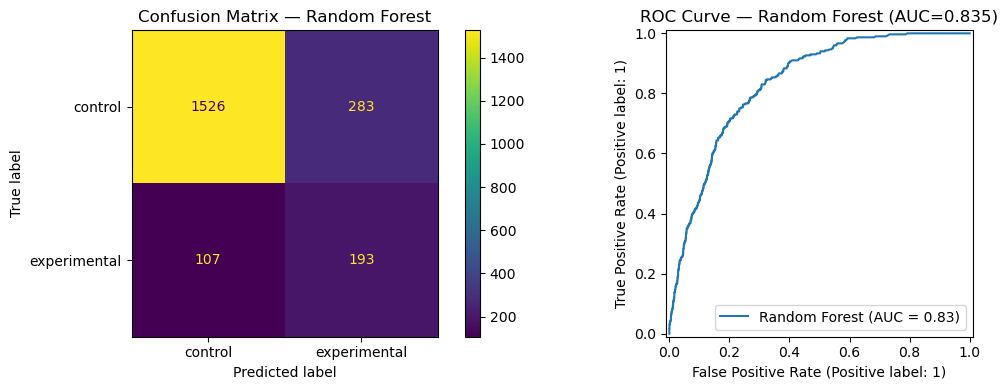

In [ ]:
# Se extrae el mejor árbol
rf_best = rf_search.best_estimator_

# Se obtienen las probabilidades de predicción para el conjunto de prueba
rf_prob = rf_best.predict_proba(X_test)[:, 1]

# Aplica la evaluación del modelo y visualiza los resultados utilizando el umbral óptimo establecido
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rf_pred, rf_threshold = evaluate_model('Random Forest', y_test, rf_prob, axes[0], axes[1])
plt.tight_layout()
plt.show()

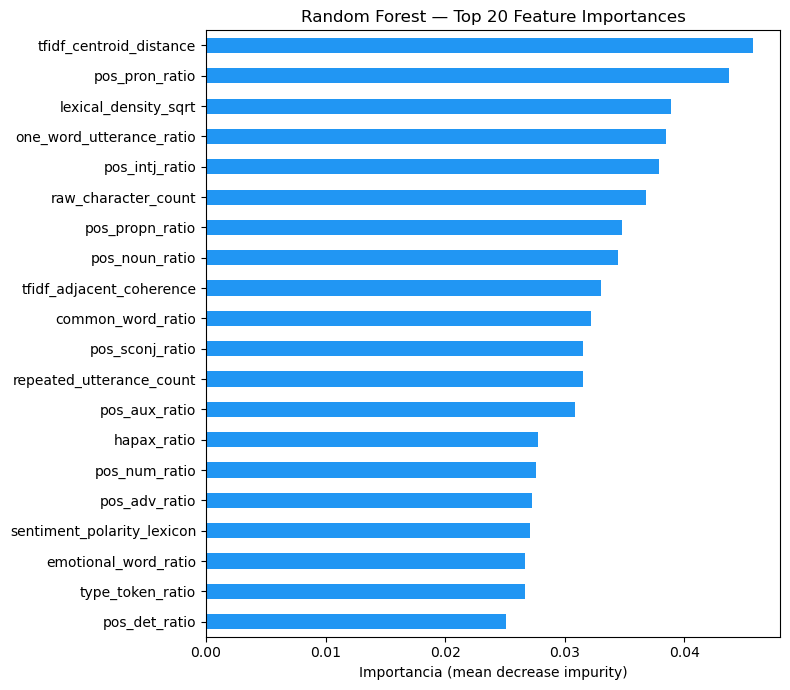

In [ ]:
# Uno de los beneficios de random forest es que se puede extraer  la importancia de cada feature 
rf_importances = pd.Series(
    rf_best.named_steps['rf'].feature_importances_, index=X.columns
)

# Visualizamos estas features más importantes
fig, ax = plt.subplots(figsize=(8, 7))
rf_importances.sort_values(ascending=False).head(20).sort_values().plot(
    kind='barh', ax=ax, color='#2196F3'
)
ax.set_title('Random Forest — Top 20 Feature Importances')
ax.set_xlabel('Importancia (mean decrease impurity)')
plt.tight_layout()
plt.show()

---
## Paso 3 — XGBoost



In [ ]:
# Creamos el modelo  y utilizamos ratio para que el modelo penalice a la clase mayoritaria como esfuerzo de disminuir el efecto del desbalance
xgb_model = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='aucpr',
    verbosity=0
)

# Creamos un greed de hiperparámetros para XGBoost
xgb_params = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

# Random search para encontrar los mejores hiperparámetros que optimicen ROC-AUC
xgb_search = RandomizedSearchCV(
    xgb_model, xgb_params,
    n_iter=20, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

# Entrenamos el modelo con el mejor hiperparámetro encontrado
xgb_search.fit(X_train, y_train)

print(f'Mejores parametros : {xgb_search.best_params_}')
print(f'Mejor ROC-AUC (CV) : {xgb_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parametros : {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Mejor ROC-AUC (CV) : 0.8413


Umbral optimo : 0.110
ROC-AUC       : 0.8596

              precision    recall  f1-score   support

     control       0.94      0.86      0.90      1809
experimental       0.45      0.69      0.54       300

    accuracy                           0.83      2109
   macro avg       0.69      0.77      0.72      2109
weighted avg       0.87      0.83      0.85      2109



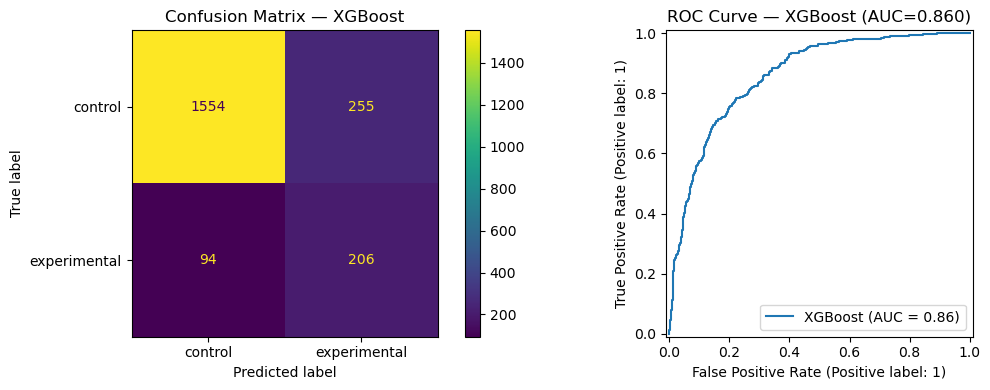

In [ ]:
# Utilizamos la función para evaluar el modelo con el mejor hiperparámetro encontrado y visualizamos los resultados
xgb_best = xgb_search.best_estimator_
xgb_prob = xgb_best.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xgb_pred, xgb_threshold = evaluate_model('XGBoost', y_test, xgb_prob, axes[0], axes[1])
plt.tight_layout()
plt.show()

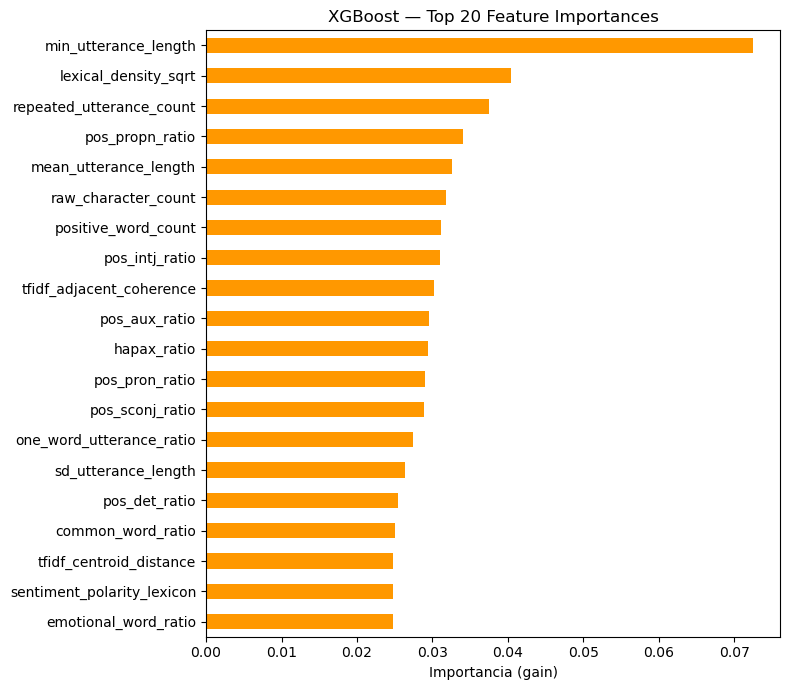

In [ ]:
# De igual forma extraemos 
xgb_importances = pd.Series(xgb_best.feature_importances_, index=X.columns)

fig, ax = plt.subplots(figsize=(8, 7))
xgb_importances.sort_values(ascending=False).head(20).sort_values().plot(
    kind='barh', ax=ax, color='#FF9800'
)
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.set_xlabel('Importancia (gain)')
plt.tight_layout()
plt.show()

---
## Sección 4 — LightGBM

LightGBM es otra implementación de gradient boosting, optimizada para ser más rápida que XGBoost. Utiliza un algoritmo de crecimiento de árbol **leaf-wise** en lugar de level-wise, lo que le permite encontrar splits más precisos.

### Estrategia contra el desbalance
- **`is_unbalance=True`**: ajusta automáticamente los pesos de clase según la frecuencia relativa, similar a `class_weight='balanced'`.

### Hiperparámetros buscados
- `num_leaves`: número de hojas por árbol (parámetro clave en LightGBM, controla complejidad)
- `min_child_samples`: mínimo de muestras en una hoja (evita sobreajuste)
- El resto son equivalentes a XGBoost

In [ ]:
# Entrenamos el modelo de LightGBM con un greed de hiperparámetros similar a los anteriores, utilizando ratio para manejar el desbalance de clases
lgbm_model = lgb.LGBMClassifier(
    is_unbalance=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_params = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [-1, 10, 20],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'num_leaves'       : [31, 63, 127],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 30],
}

# Random search para encontrar los mejores hiperparámetros que optimicen ROC-AUC
lgbm_search = RandomizedSearchCV(
    lgbm_model, lgbm_params,
    n_iter=20, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

lgbm_search.fit(X_train, y_train)

print(f'Mejores parametros : {lgbm_search.best_params_}')
print(f'Mejor ROC-AUC (CV) : {lgbm_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parametros : {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Mejor ROC-AUC (CV) : 0.8393


Umbral optimo : 0.009
ROC-AUC       : 0.8543

              precision    recall  f1-score   support

     control       0.93      0.89      0.91      1809
experimental       0.47      0.61      0.53       300

    accuracy                           0.85      2109
   macro avg       0.70      0.75      0.72      2109
weighted avg       0.87      0.85      0.86      2109



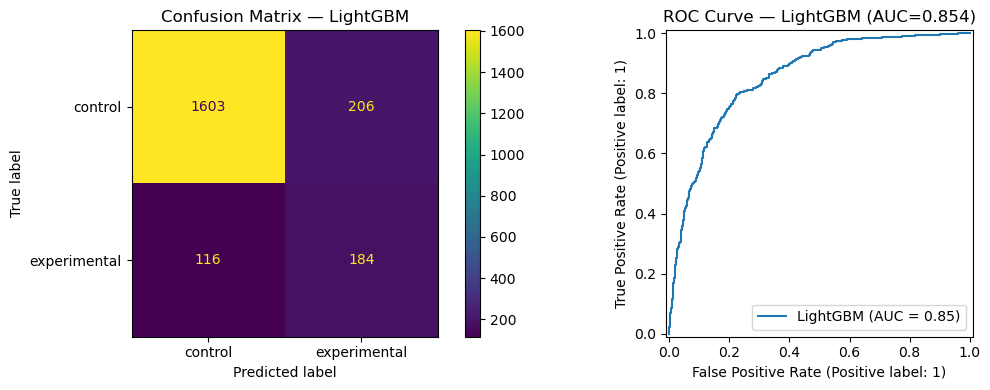

In [ ]:
# Utilizamos la función para evaluar el modelo con el mejor hiperparámetro encontrado y visualizamos los resultados
lgbm_best = lgbm_search.best_estimator_
lgbm_prob = lgbm_best.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lgbm_pred, lgbm_threshold = evaluate_model('LightGBM', y_test, lgbm_prob, axes[0], axes[1])
plt.tight_layout()
plt.show()

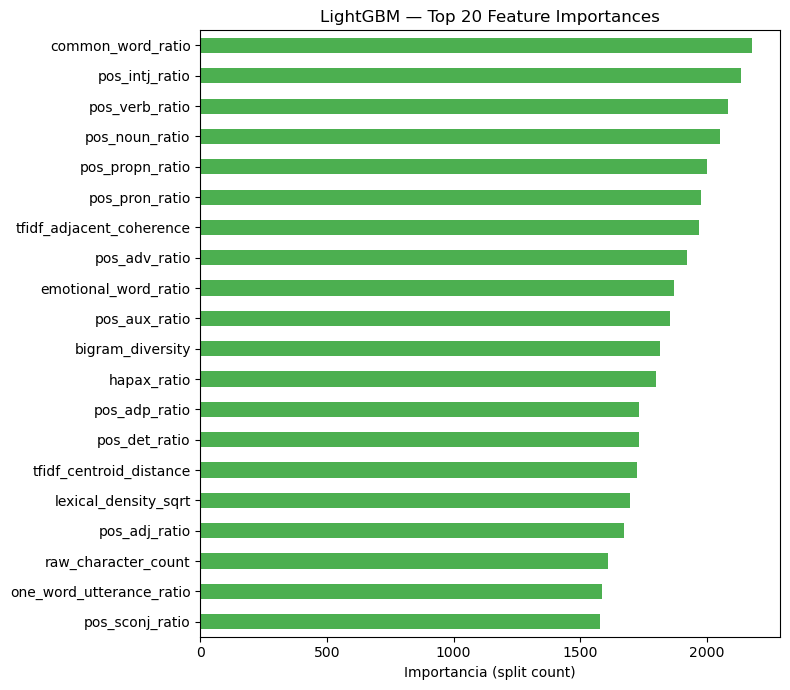

In [ ]:
# Extraemos la importancia de las features para LightGBM, esta se basa en el conteo de splits que cada feature realiza en los árboles del modelo
lgbm_importances = pd.Series(lgbm_best.feature_importances_, index=X.columns)

fig, ax = plt.subplots(figsize=(8, 7))
lgbm_importances.sort_values(ascending=False).head(20).sort_values().plot(
    kind='barh', ax=ax, color='#4CAF50'
)
ax.set_title('LightGBM — Top 20 Feature Importances')
ax.set_xlabel('Importancia (split count)')
plt.tight_layout()
plt.show()

---
## Paso 5 — Comparación de modelos

Se comparan los tres modelos 



In [25]:
# Convertimos nuestra lista de resultados en un DF para visualizar
results_df = pd.DataFrame(results_list).set_index('Modelo')

print('=' * 70)
print('TABLA COMPARATIVA DE MODELOS')
print('=' * 70)
print(results_df.to_string())
print('=' * 70)


TABLA COMPARATIVA DE MODELOS
               ROC-AUC  Precision (exp)  Recall (exp)  F1 (exp)  F1 macro  Umbral
Modelo                                                                           
Random Forest   0.8349           0.4055        0.6433    0.4974    0.6921   0.432
XGBoost         0.8596           0.4469        0.6867    0.5414    0.7202   0.110
LightGBM        0.8543           0.4718        0.6133    0.5333    0.7210   0.009


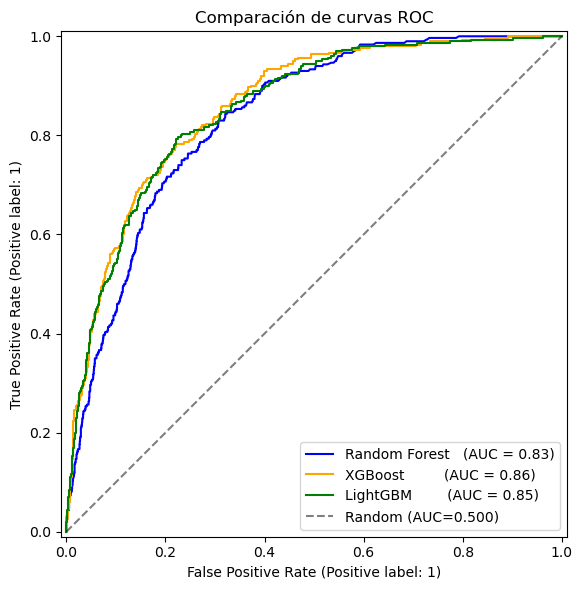

In [26]:
# Juntamos todas las curvas ROC en una sola gráfica para comparar el desempeño de los modelos
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test, rf_prob, ax=ax,
    name=f'Random Forest  ',
    color="blue"
)
RocCurveDisplay.from_predictions(
    y_test, xgb_prob, ax=ax,
    name=f'XGBoost        ',
    color="orange"
)
RocCurveDisplay.from_predictions(
    y_test, lgbm_prob, ax=ax,
    name=f'LightGBM       ',
    color="green"
)
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', alpha=0.5)
ax.set_title('Comparación de curvas ROC')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Paso 6 — Evaluación de features con shap


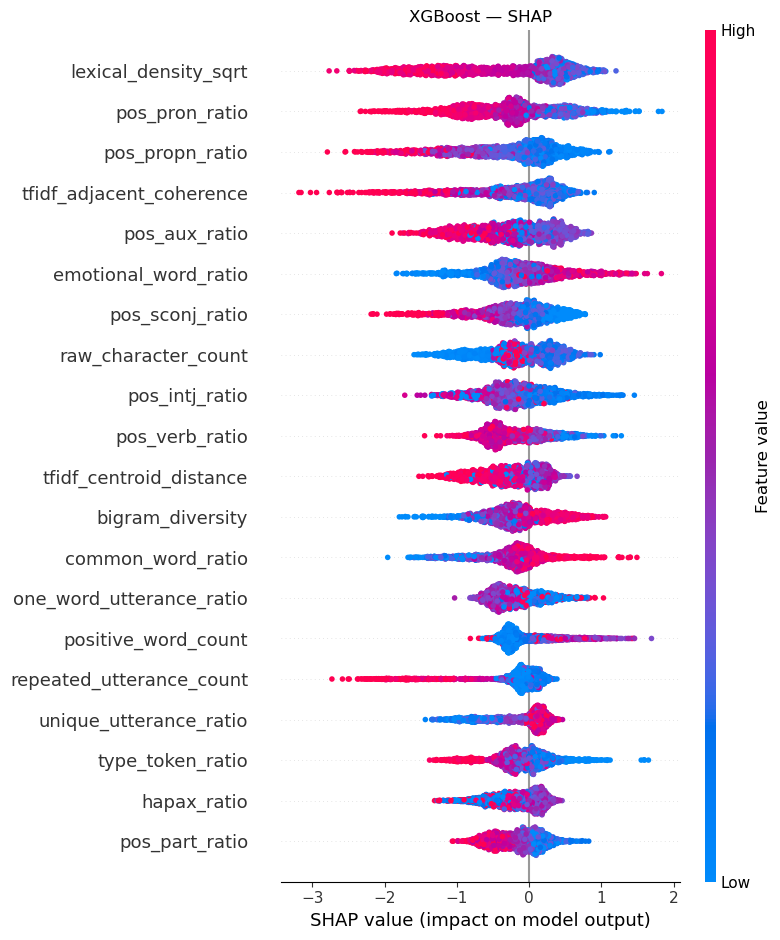

In [32]:
import shap

# Buscamos los valores shap para confirmar la dirección e influencia de las features para el mejor modelo de XGBoost
explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test)
# Mostramos una tabla con las top 20 features
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('XGBoost — SHAP')
plt.tight_layout()
plt.show()